This notebook tackles the [**Playground Series – Season 6, Episode 4: Predicting Irrigation Need**](https://www.kaggle.com/competitions/playground-series-s6e4), a competition focused on predicting a class label (`Low`, `Medium`, `High`) for the `Irrigation_Need` target, based on features describing the soil, weather, crops, and other qualities of the field where the crop is growing.

## The Approach

I plan to split the various phases of model development into a separate notebooks to streamline later work (EDA can be *time consuming*), and allow conducting multiple studies at one time.  We will follow a structured machine learning workflow across several notebooks:

1.  **Exploratory Data Analysis (EDA):** We will begin by conducting a deep dive into the dataset using `ydata_profiling` and custom visualizations. This will help us understand the data's structure, identify patterns, analyze feature distributions, check for correlations, and assess overall data quality.  **(This notebook)**
    
2.  **Data Preprocessing & Feature Engineering:** Based on insights from the EDA, we will prepare the data for modeling. This will involve strategies like encoding categorical variables and splitting combined features to extract maximum predictive value.  A `FeatureEngineering` utility class will be created so that strategies can be shared among the various model notebooks.
    
3.  **Model Development & Tuning:** Once we have evaluated the data and performed feature engineering, we will build and train a robust predictive model. In past competitions, we've started with a **LightGBM** (Light Gradient Boosting Machine) model, renowned for its high performance and efficiency. We will also leverage **Optuna** for automated hyperparameter tuning to find the best-performing model configuration.  In the last competition, I also added notebooks to train **XGBoost** and **CatBoost** models.  I will also develop a model-blending notebook to blend the predictions, which provided the best scores.
    
4.  **Submission:** Finally, we will use our tuned model to generate predictions (probabilities) on the test set and format them into a `submission.csv` file for the competition.
    
Let's begin by loading the necessary libraries and exploring the data.

## Install Needed Packages

In [1]:
%pip -q install --upgrade ydata_profiling


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
from IPython.display import display
from ydata_profiling import ProfileReport
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e04_experiment_setup import ExperimentSetup
from ps_s06e04_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Irrigation_Need'

# Show GPU be utilized in training
USE_GPU = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy    4.920         32.580           1.010   
1   1      Clay    7.080         56.610           0.440   
2   2      Clay    5.690         27.710           0.810   
3   3     Sandy    5.650         13.320           1.330   
4   4      Clay    7.960         59.140           0.380   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    3.050         15.010    50.610      725.990   
1                    2.000         22.920    67.860      985.660   
2                    2.830         26.970    92.220    2,201.700   
3                    0.870         13.320    61.570    1,357.330   
4                    0.960         20.220    91.110    1,538.200   

   Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
0           5.900          16.790  Sugarcane            Sowing    Zaid   
1           6.980           3.390      Wheat        Vegetative  Kharif

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  630000      Silt    6.360         26.190           0.590   
1  630001      Clay    5.870          9.880           1.180   
2  630002     Sandy    6.220         26.550           0.960   
3  630003      Clay    7.680         53.580           0.830   
4  630004     Loamy    5.230         59.020           0.540   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    2.810         17.830    30.240    1,533.380   
1                    3.260         21.180    78.070      576.050   
2                    0.850         26.870    60.350      545.300   
3                    0.550         41.740    36.050    1,211.030   
4                    2.110         41.080    52.470    1,321.910   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0           5.400           3.000     Maize            Sowing    Rabi   
1           7.220          15.880    Cotton         

## Read and Examine the Original Dataset

In [6]:
original_df = helper.read_dataset('original')

ORIGINAL DATASET

  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0      Clay    6.140         36.480           0.420                    2.170   
1      Silt    6.410         50.560           0.380                    0.230   
2     Sandy    7.710         40.070           1.090                    2.180   
3      Clay    5.960         12.750           1.560                    0.400   
4      Clay    7.760         18.580           0.950                    2.520   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0         21.900    31.190    1,167.700           4.010           1.970   
1         36.500    26.010      831.280          10.720          16.820   
2         41.830    76.410    1,844.450           7.750          19.030   
3         37.220    43.320      306.260           8.900          11.440   
4         22.380    86.440    1,875.630          10.390          11.260   

  Crop_Type Crop_Growth_Stage  Season Irrigation_T

## Exploratory Data Analysis

In a previous Playground Episode, I ran across a report generator that shows histograms, tables of most common values, and various interaction plots.  Even better, it can be used to determine if the test dataset differs from the training set, and if so, how.  I spent hours poring over them, and they helped to determine which columns to concentrate on for feature engineering.  And since it creates an HTML report, it can be viewed outside the notebook, from github, for instance.

In [7]:
# Create the profile report object for the TRAINING data
training_report = ProfileReport(training_df, title='Training Data')

# Create the profile report object for the TEST data
test_report = ProfileReport(test_df, title='Test Data')

# Create the comparison report
# This compares the TEST report *against* the TRAINING report
train_test_comparison_report = training_report.compare(test_report)

# Save the combined report to an HTML file
train_test_comparison_report.to_file('training_vs_test_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:13<00:00,  1.61it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Display the HTML report in an iframe
IFrame(src='training_vs_test_comparison.html', width=1000, height=600)

We also load the original dataset to compare distributions. Note: Ensure you have added the [Heart Disease Prediction Dataset](/kaggle/input/heartdisease/Heart_Disease_Prediction.csv) to your notebook input for this cell to run.

In [9]:
# Create the profile report object for the ORIGINAL data
original_report = ProfileReport(test_df, title='Original Data')

# Create the comparison report
# This compares the ORIGINAL report *against* the TRAINING report
train_original_comparison_report = training_report.compare(original_report)

# Save the combined report to an HTML file
train_original_comparison_report.to_file('training_vs_original_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Display the HTML report in an iframe
IFrame(src='training_vs_original_comparison.html', width=1000, height=600)

## Data Visualization
While the automated report provides a great overview, we will use a custom `DataVisualizer` class to dig deeper into specific relationships.

1. **Target Encoding:** We convert the `Irrigation_Need` target from `Low`, `Medium`, and `High` to `0`, `1`, and `2`. This allows us to calculate mean risk rates and correlations numerically.
2. **Signal Ranking:** We will rank features by their Spearman correlation (for numerical features) and range of risk (for categorical features) to identify the strongest predictors.
3. **Interaction Plots:** We will generate specific plots to see how top features interact with the target.

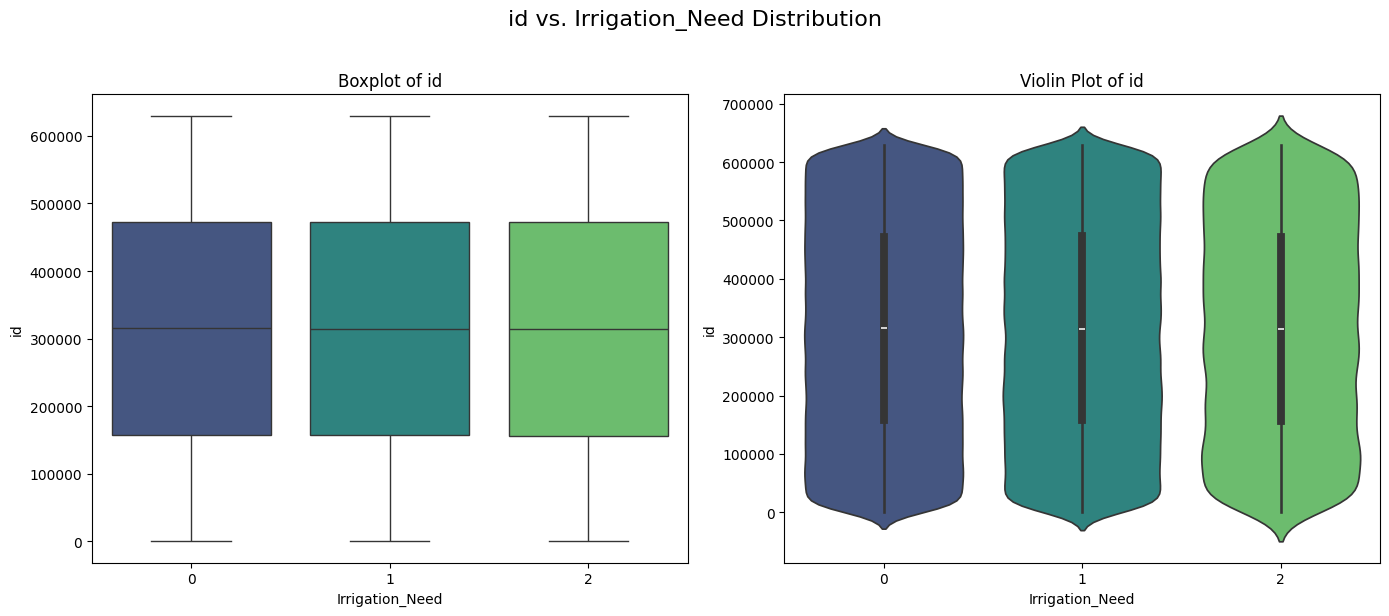

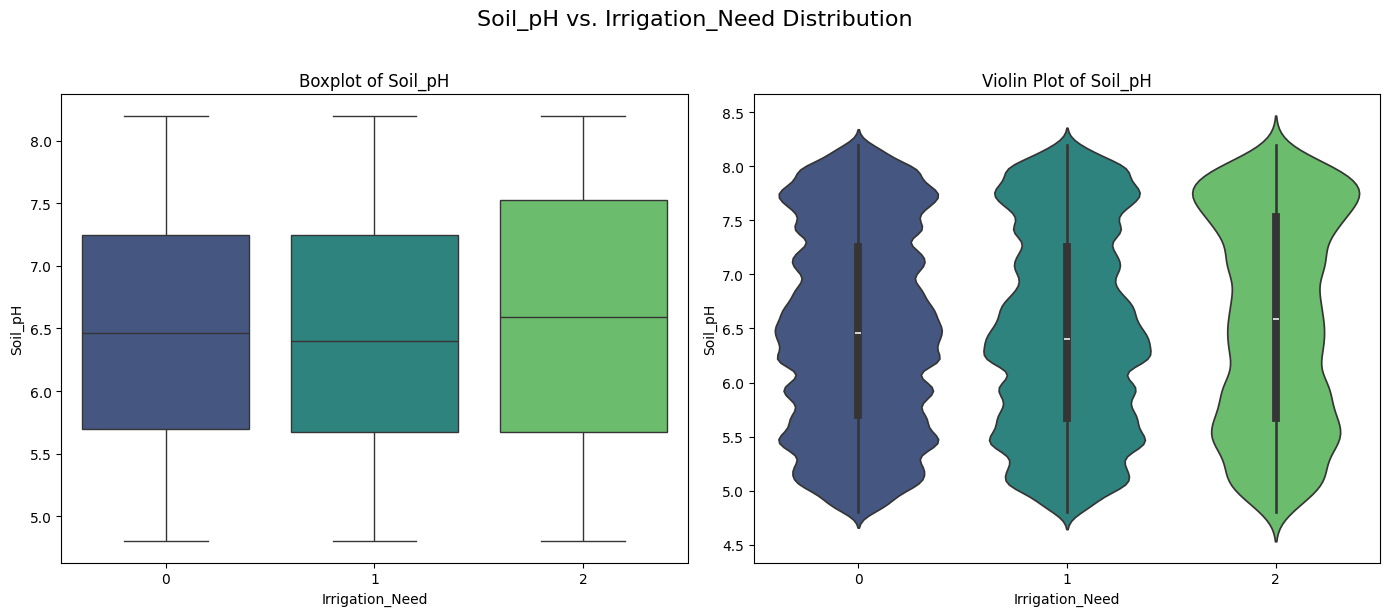

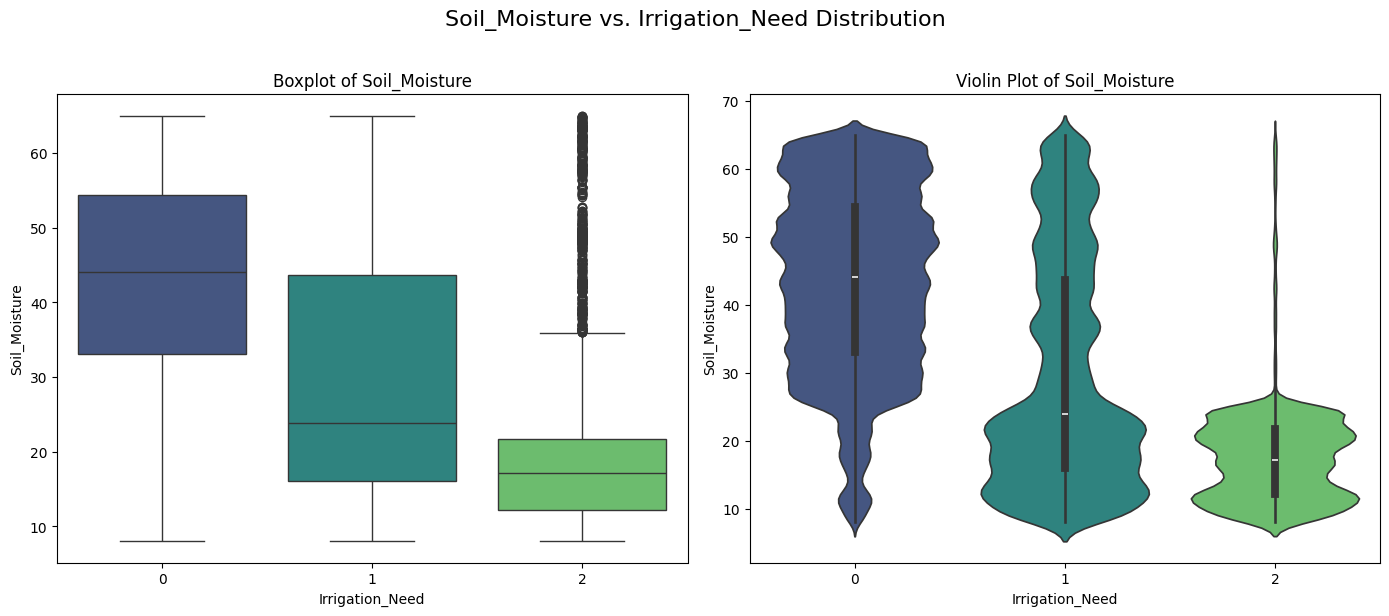

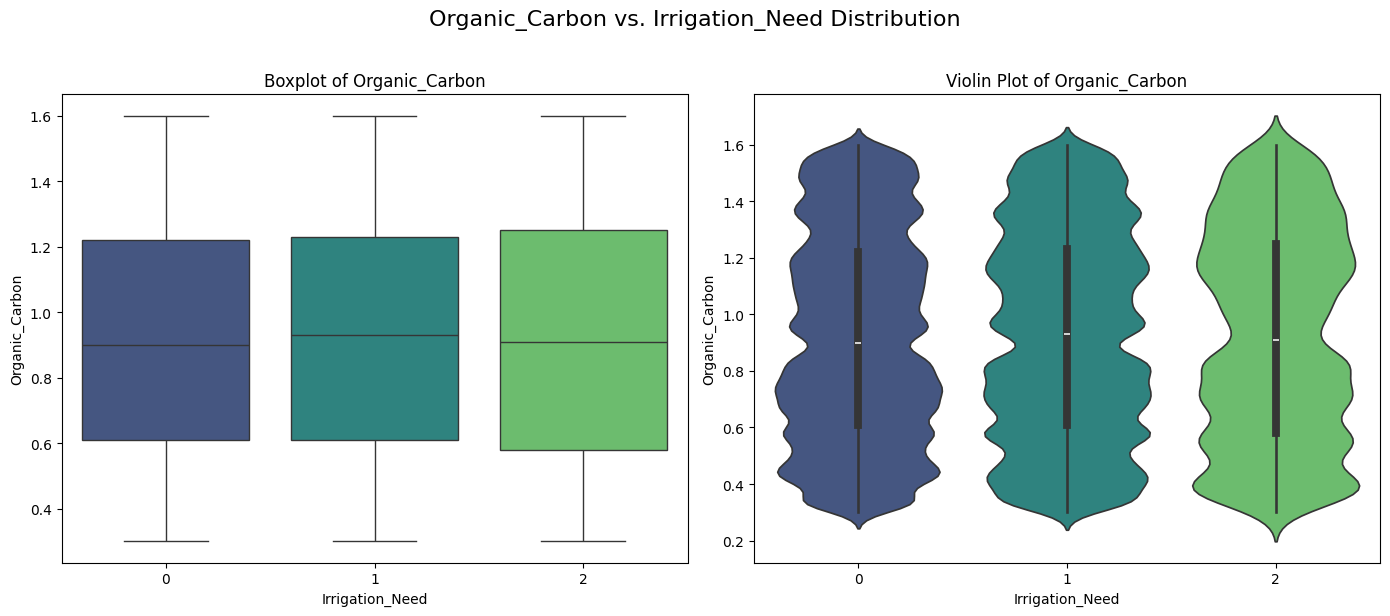

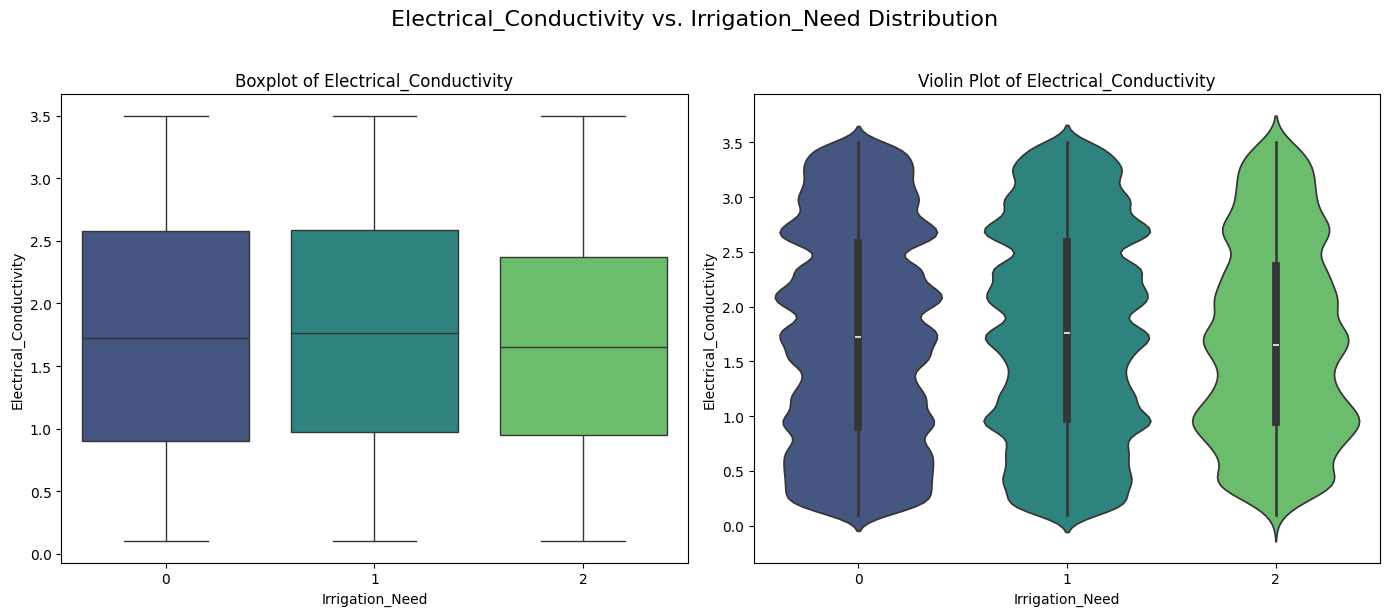

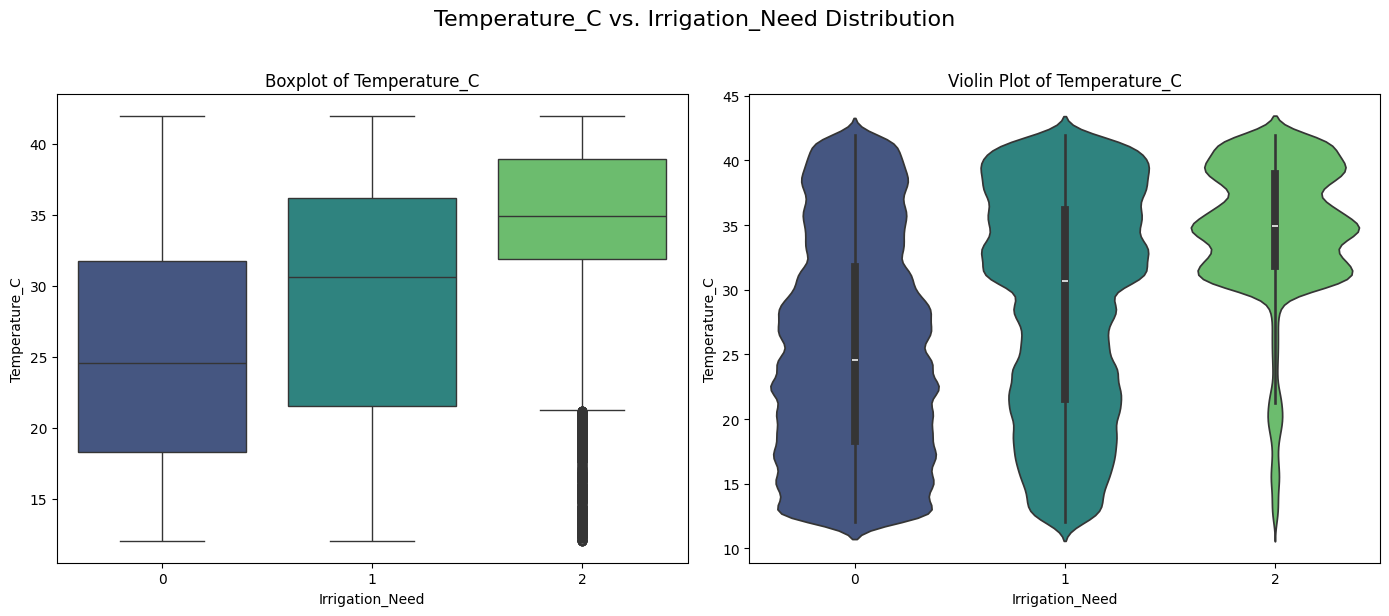

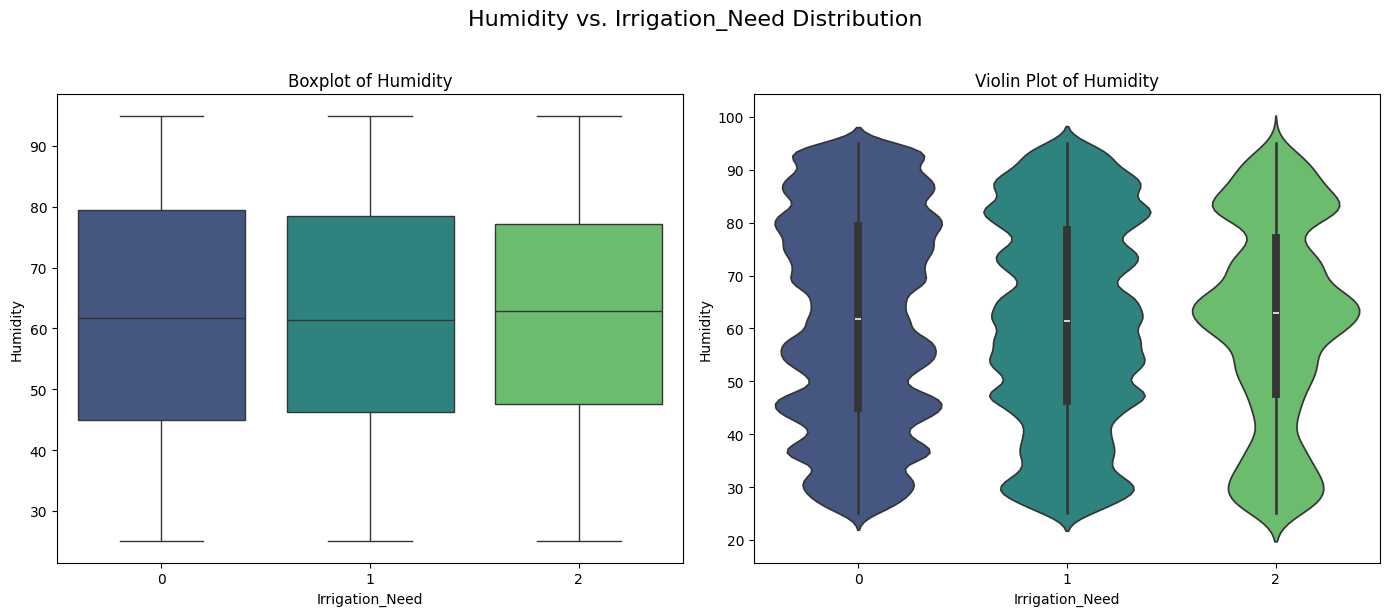

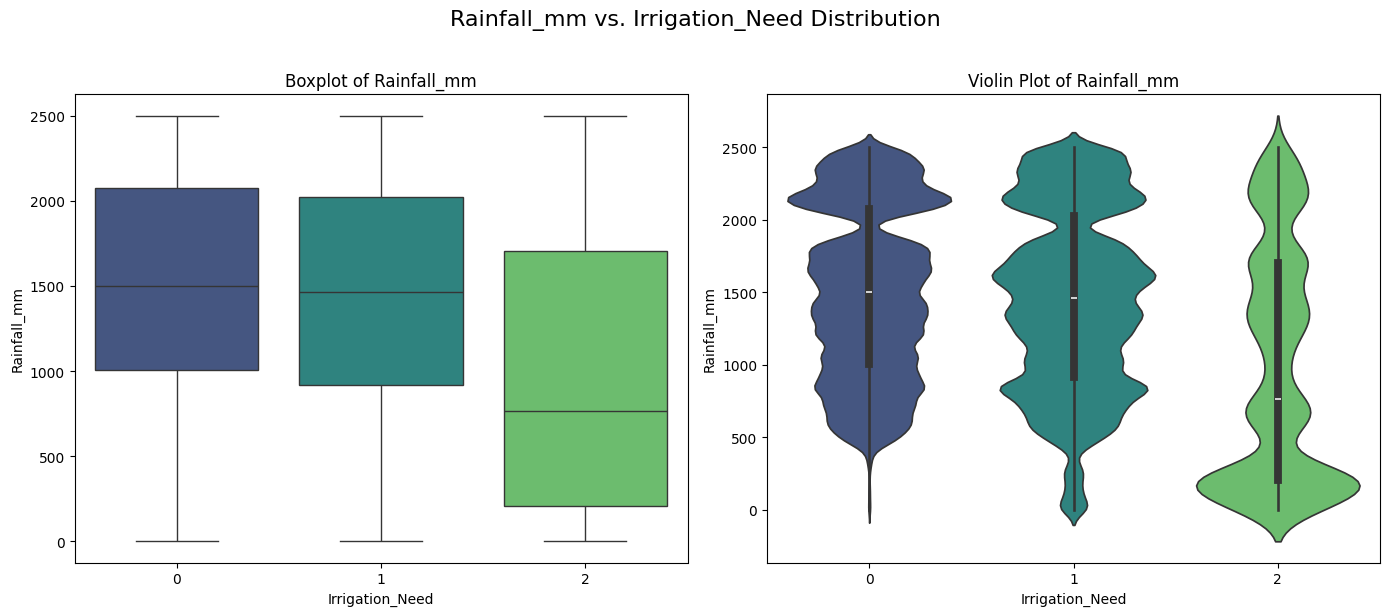

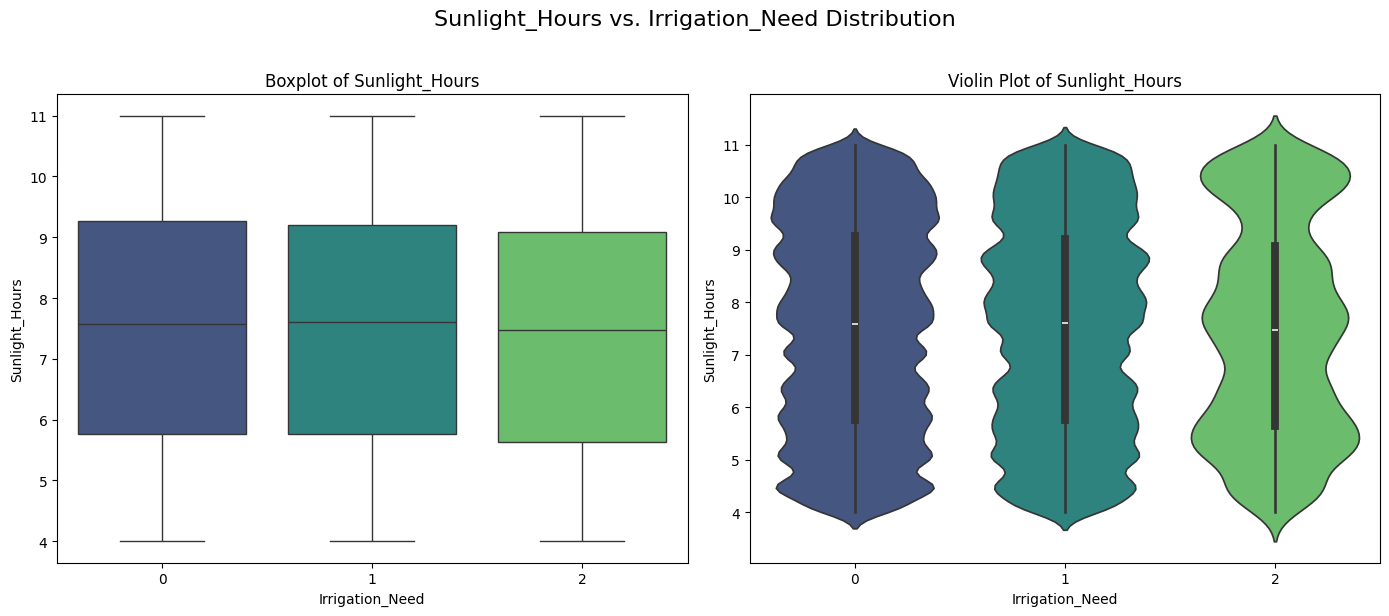

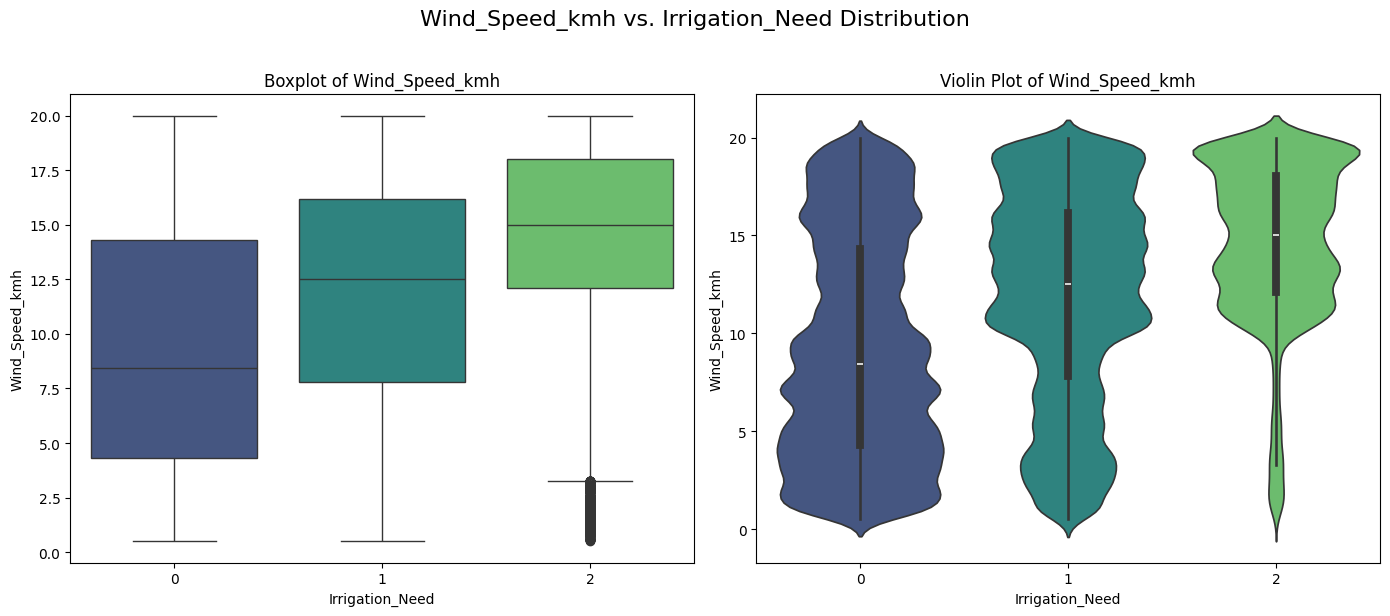

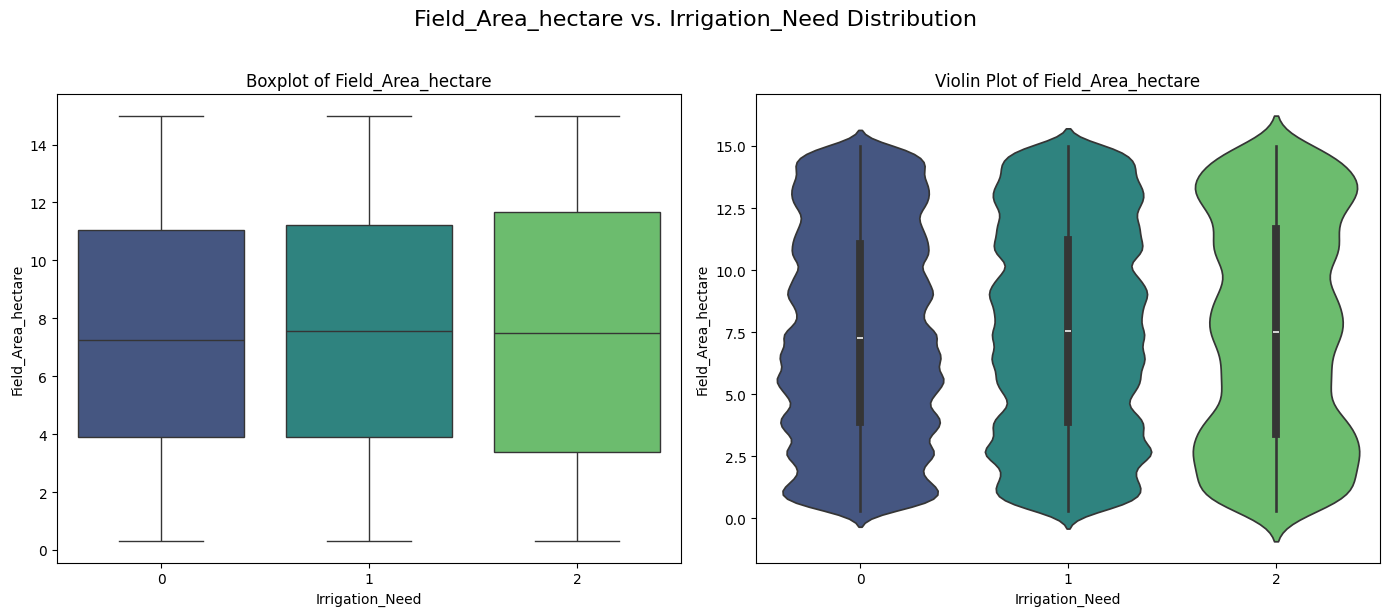

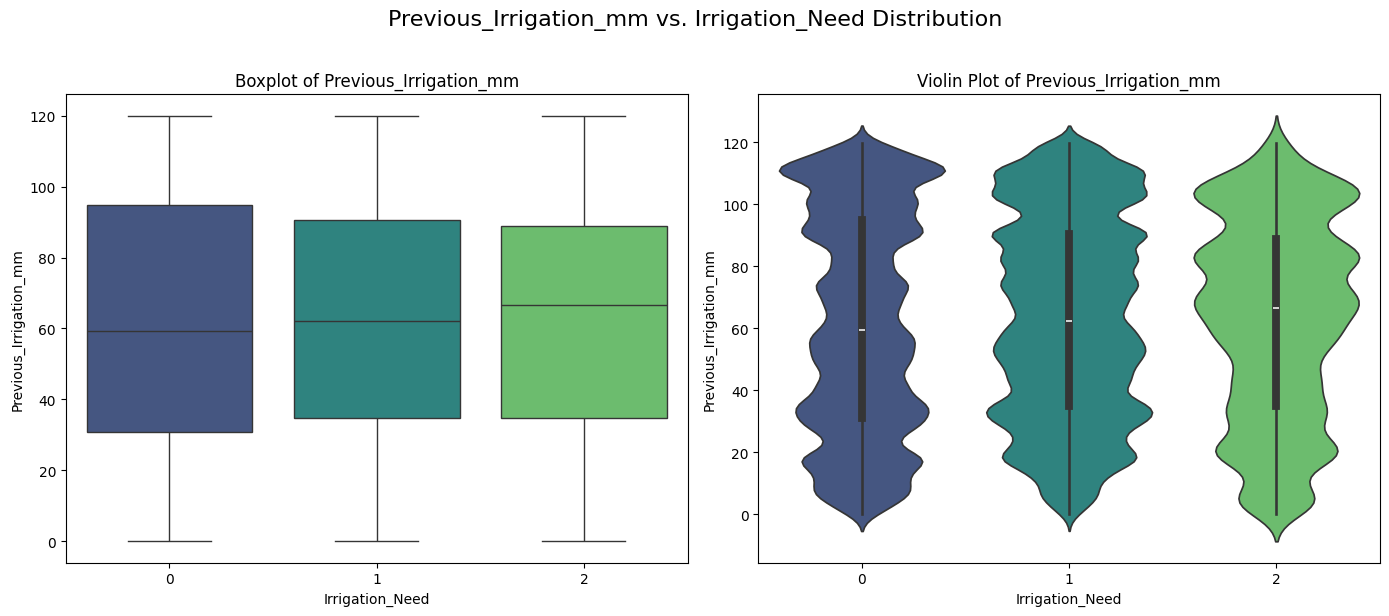

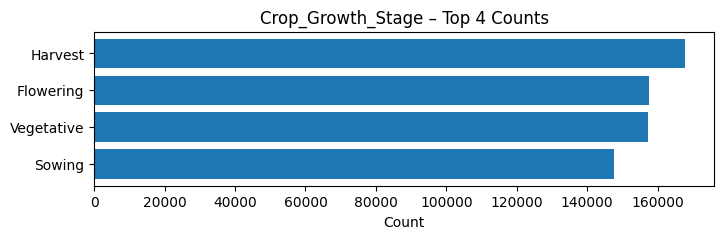

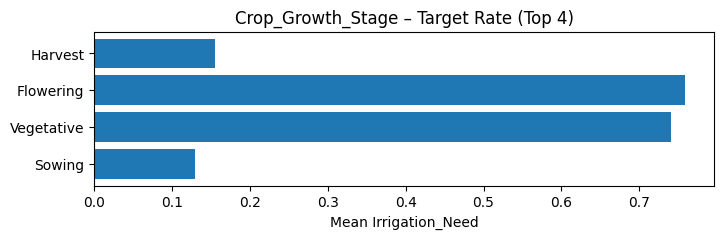

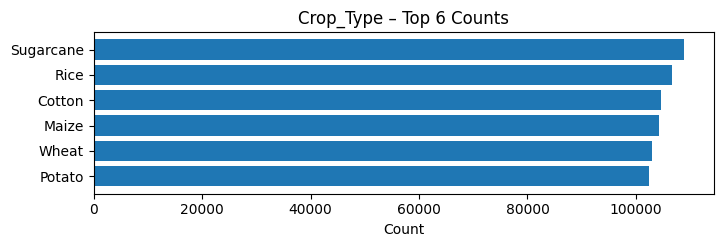

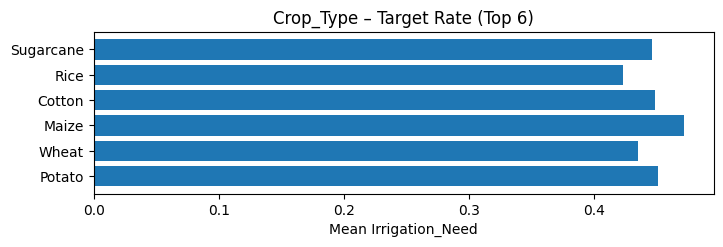

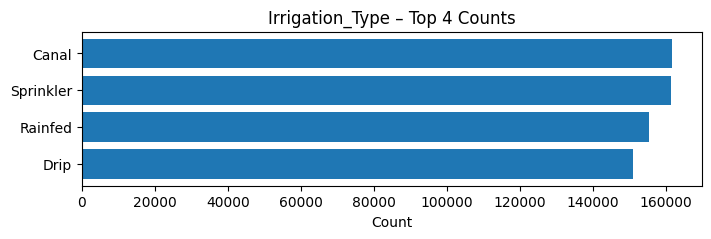

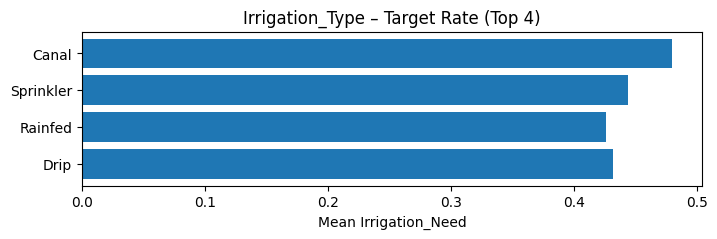

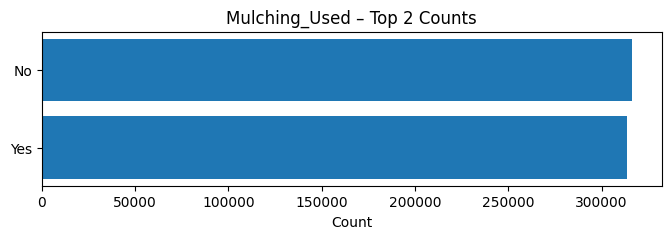

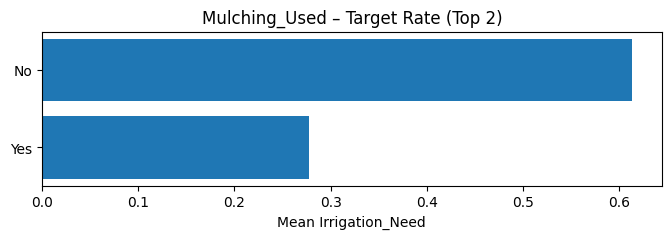

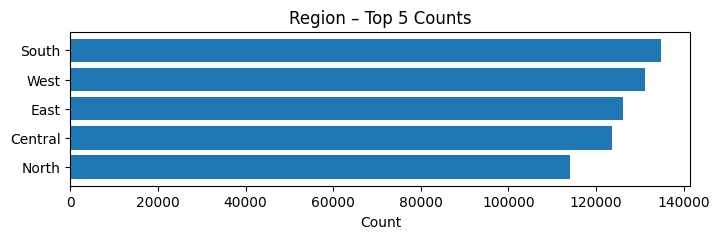

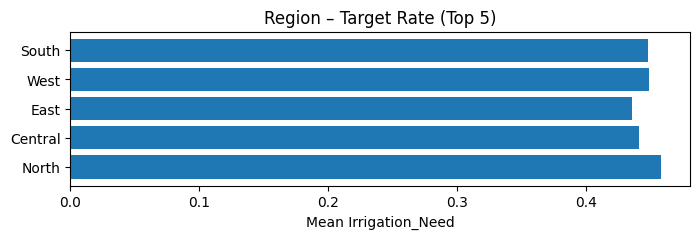

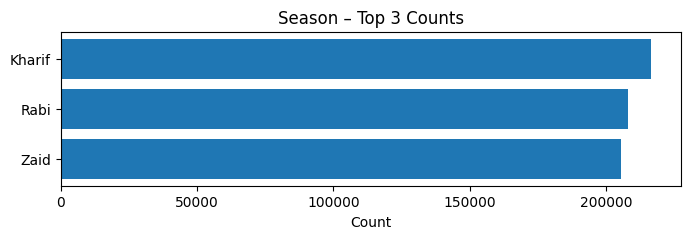

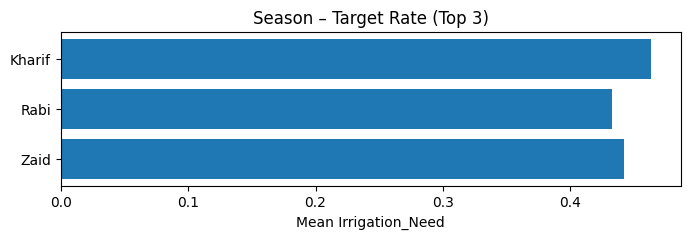

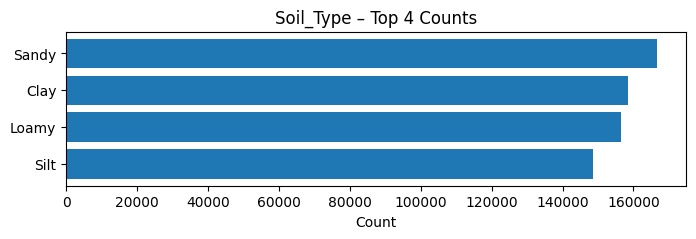

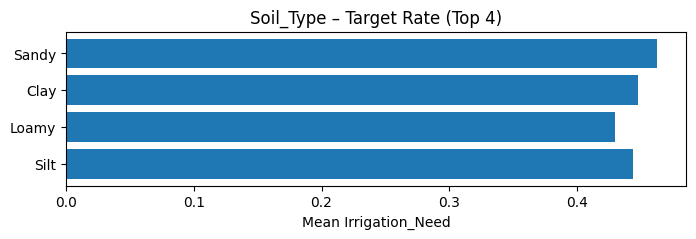

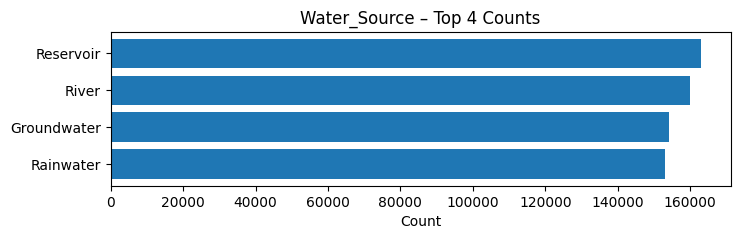

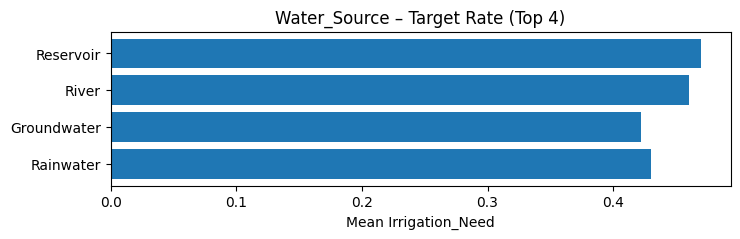

### Numeric x Category Trend

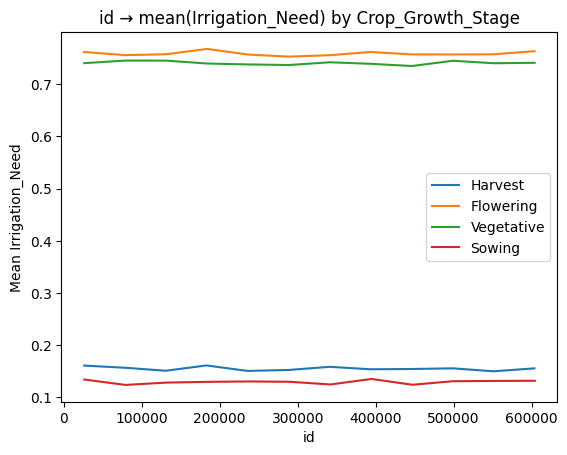

### Category x Category Trend

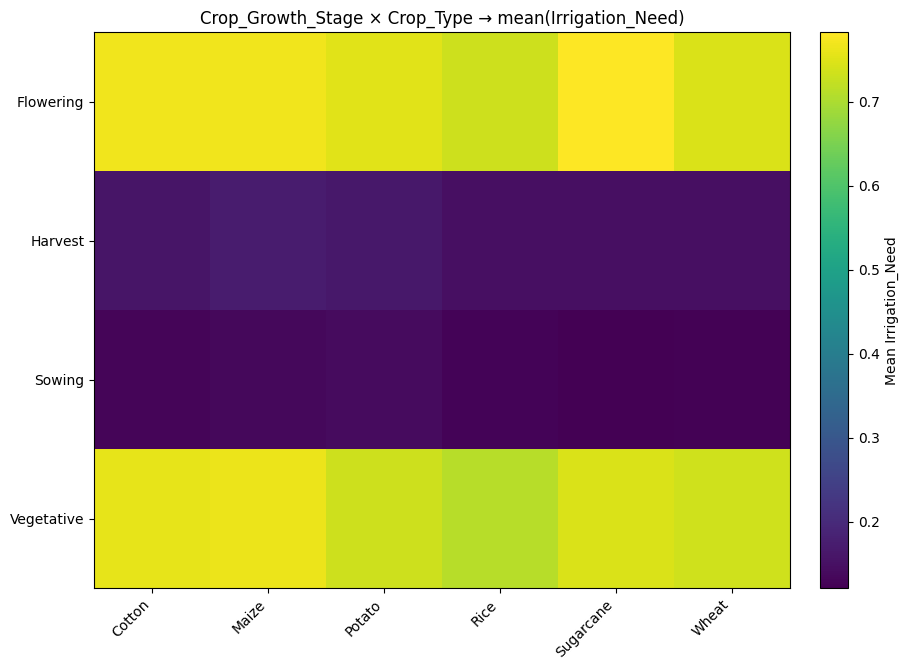

### Feature Signal Ranking

Top numeric (|Spearman|): [('Soil_Moisture', -0.44553717295551515), ('Wind_Speed_kmh', 0.25164829890927426), ('Temperature_C', 0.24211719556508654), ('Rainfall_mm', -0.07528307963914024), ('Humidity', -0.021380325861684), ('Field_Area_hectare', 0.018978806719075512), ('Previous_Irrigation_mm', 0.018962990870876318), ('Electrical_Conductivity', 0.01466697954319027), ('Organic_Carbon', 0.007016005002881766), ('Soil_pH', -0.004547638468643446)]
Top categorical (range of mean risk): [('Crop_Growth_Stage', 0.6286196773416781, 4), ('Mulching_Used', 0.3361576520338664, 2), ('Irrigation_Type', 0.05374090023426431, 4), ('Crop_Type', 0.04857525772200649, 6), ('Water_Source', 0.047528357758154005, 4), ('Soil_Type', 0.03277338170864291, 4), ('Season', 0.031131934940302697, 3), ('Region', 0.022786291367330458, 5)]


In [11]:
# Define mapping for the target
# Low -> 0, Medium -> 1, High -> 2 (or as appropriate for your task)
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Apply mapping to the target column
training_df[TARGET] = training_df[TARGET].map(target_mapping)

visualizer = DataVisualizer(target=TARGET, seed=helper.get_seed())
visualizer.run_data_visualization(training_df)

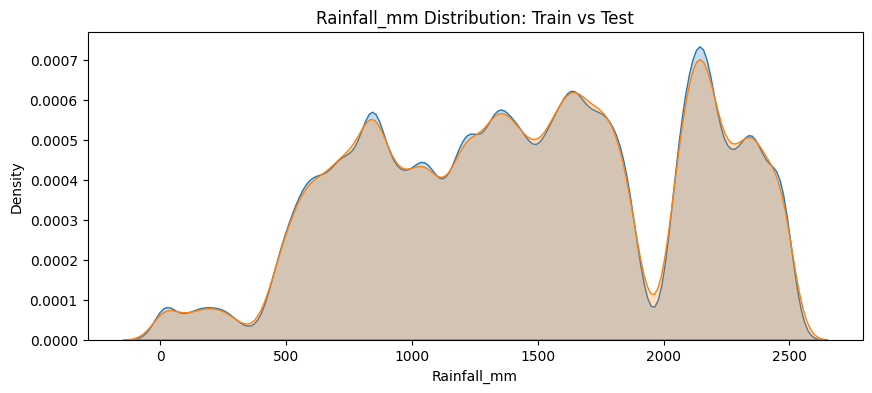

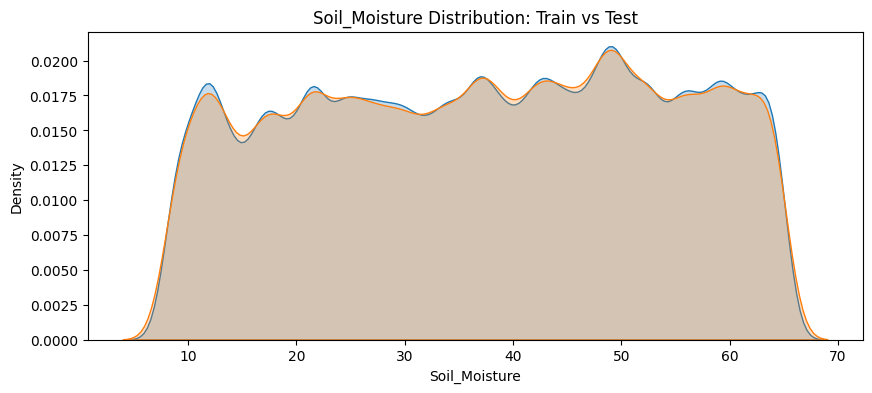

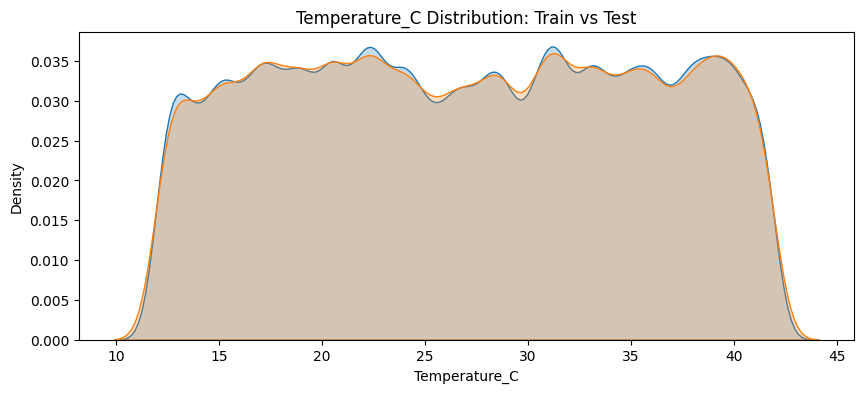

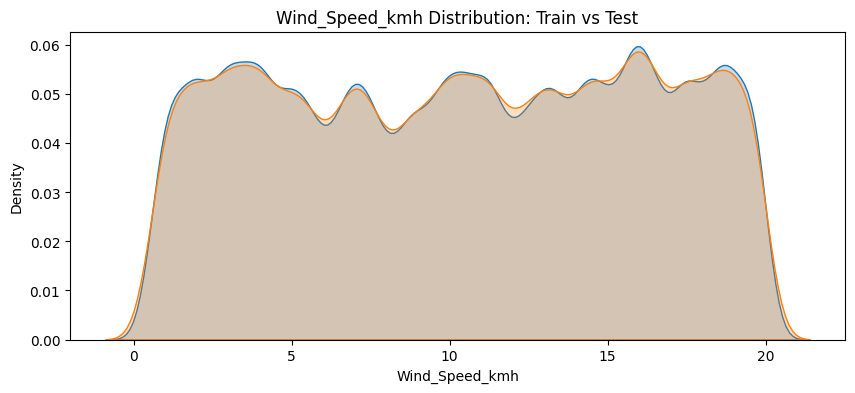

In [16]:
# Check for drift visually in top correlated features
tops=[
    'Rainfall_mm',
    'Soil_Moisture',
    'Temperature_C',
    'Wind_Speed_kmh'
]
for top in tops:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(training_df[top], label='Train', fill=True)
    sns.kdeplot(test_df[top], label='Test', fill=True)
    plt.title(f'{top} Distribution: Train vs Test')
    plt.show()

